<a href="https://colab.research.google.com/github/sanjayyy-13/DEEP-LEARNING-24BAD407/blob/main/EX-4/24BAD407_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt
import numpy as np

# PART A: DATASET PREPARATION
# Loading CIFAR-10 as a sample dataset for image recognition
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Preprocessing: Normalize pixel values and Resize images for ResNet (optional but recommended)
# ResNet-50 expects 224x224, but we can use smaller for demonstration speed
x_train = tf.image.resize(x_train[:5000], (72, 72)) / 255.0
x_test = tf.image.resize(x_test[:1000], (72, 72)) / 255.0
y_train = y_train[:5000]
y_test = y_test[:1000]

print(f"Training data shape: {x_train.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 869s 5us/step
Training data shape: (5000, 72, 72, 3)


In [ ]:
# PART B: IMPLEMENTING TRANSFER LEARNING
# 1. Load Pre-trained ResNet-50
base_model = applications.ResNet50(weights='imagenet', include_top=False, input_shape=(72, 72, 3))

# 2. Freeze the feature extraction layers
base_model.trainable = False

# 3. Add custom classification head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 126s 945ms/step - accuracy: 0.1058 - loss: 2.3317 - val_accuracy: 0.1400 - val_loss: 2.2804
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 133s 873ms/step - accuracy: 0.1433 - loss: 2.2639 - val_accuracy: 0.1730 - val_loss: 2.2379
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.1465 - loss: 2.2215 - val_accuracy: 0.2180 - val_loss: 2.1940
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.1765 - loss: 2.1903 - val_accuracy: 0.2270 - val_loss: 2.1375
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.1880 - loss: 2.1566 - val_accuracy: 0.2390 - val_loss: 2.1120


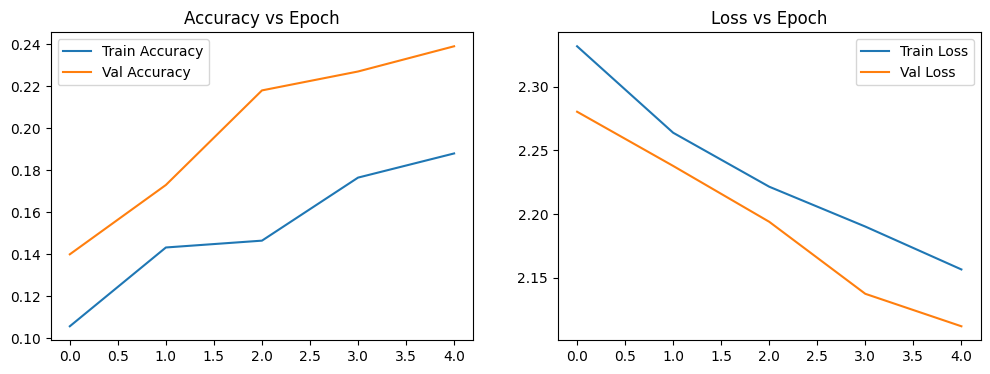

In [ ]:
# PART C: MODEL TRAINING AND PERFORMANCE EVALUATION
history = model.fit(x_train, y_train, epochs=5, validation_split=0.2, batch_size=32)

# Visualize Results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

## PART D: USING HUGGING FACE PRE-TRAINED MODELS
We will use the `transformers` library to load a ViT (Vision Transformer) or a ResNet model directly from Hugging Face for inference.

In [ ]:
!pip install -q transformers
from transformers import pipeline

# Load a pre-trained image classification pipeline
classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

# Example prediction (requires an image URL or local path)
# result = classifier("https://datasets-server.huggingface.co/assets/cifar10/.../image.jpg")
print("Hugging Face Pipeline loaded successfully.")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Hugging Face Pipeline loaded successfully.


### Final Prediction using Hugging Face
Below is a sample prediction using the pre-trained Vision Transformer from Hugging Face to compare with our fine-tuned ResNet model.

In [ ]:
# Using a sample image from the test set for the Hugging Face model
from PIL import Image
import numpy as np

sample_img = (x_test[0].numpy() * 255).astype(np.uint8)
pil_img = Image.fromarray(sample_img)

# Run classification
hf_results = classifier(pil_img)
print("Hugging Face Predictions:")
for res in hf_results:
    print(f"{res['label']}: {res['score']:.4f}")

Hugging Face Predictions:
polecat, fitch, foulmart, foumart, Mustela putorius: 0.0922
tabby, tabby cat: 0.0580
black-footed ferret, ferret, Mustela nigripes: 0.0445
weasel: 0.0356
velvet: 0.0331
